# Documentation: Tools in LangChain

In LangChain, **Tools** are the interfaces that allow LLMs to interact with external systems. While LLMs are excellent at reasoning, they are limited to their training data. Tools give them "hands" to fetch real-time data, query databases, or perform computations.

---

## The Anatomy of a Tool

A tool consists of two essential components that bridge the gap between human-readable descriptions and executable code:

### 1. The Schema (The "Instruction Manual")
The LLM does not see the underlying logic of your tool. Instead, it reads a **JSON Schema** that tells it:
* **Name:** A unique, descriptive identifier (e.g., `calculate_tax`).
* **Description:** A text explanation of *when* and *why* the model should use this tool.
* **Arguments:** Definitions of the required inputs (types, keys, and descriptions).

### 2. The Implementation (The "Engine")
This is the actual **Python function** or **Coroutine** that performs the work. When the LLM decides to use a tool, it generates a "Tool Call" containing the arguments. LangChain then executes your function using those arguments.

---

## Tool Calling Workflow

The interaction between the model and a tool follows a specific sequence:

1.  **Bind:** Tools are "bound" to a model so the model knows they exist.
2.  **Request:** The model decides a tool is needed and outputs a `tool_call`.
3.  **Execute:** The system runs the function associated with that tool.
4.  **Observe:** The tool output is fed back to the model as a `ToolMessage`.
5.  **Finalize:** The model uses the tool output to generate a final response.

---

## Code Implementation Example

Using the `@tool` decorator is the most straightforward way to define a tool in LangChain.

```python
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

# Define the Tool (Schema + Implementation)
@tool
def get_weather(city: str):
    """Fetch the current weather for a specific city."""
    # In a real app, this would call an API like OpenWeatherMap
    return f"The weather in {city} is 72°F and sunny."

# Initialize Model
llm = ChatOpenAI(model="gpt-4o")

# Bind the tool to the model
llm_with_tools = llm.bind_tools([get_weather])

# Example usage
query = "What is the weather like in New York?"
response = llm_with_tools.invoke(query)

# The response will contain 'tool_calls' if the LLM wants to use the tool
print(response.tool_calls)

# Documentation: Best Practices for LangChain Tool Definitions

Defining tools effectively is the most important step in ensuring an LLM or Agent functions reliably. Use the following guidelines to optimize your tool definitions for accuracy and performance.

---

## Best Practices

### 1. Be Specific in Descriptions
The LLM relies almost entirely on the tool description to decide which tool to pick. A vague description leads to hallucinations or skipped steps.
* **Avoid:** `"Search"`
* **Better:** `"Search Google for current news and real-time events that occurred after the model's training cutoff."`

### 2. Utilize Python Type Hinting
LangChain uses Python's native type hints to construct the JSON schema that is sent to the LLM. Without these, the model won't know if it should provide a string, an integer, or a list.
* **Best Practice:** Always use types like `str`, `int`, `bool`, or `List[str]`.

### 3. Implement Graceful Error Handling
If a tool fails and throws a raw Python error, the agent may crash. If the tool catches the exception and returns a text description of the error, the LLM can read that error and attempt to fix its input or try a different approach.

### 4. Keep Tools Atomic
Avoid "Swiss Army Knife" tools that try to do too much. Each tool should perform one specific action well. This reduces complexity in the arguments the LLM has to generate.
* **Avoid:** `database_manager`
* **Better:** Create separate tools like `query_users` and `update_inventory`.

---

## Tool Component Summary

The following table breaks down the core components of a tool and who is responsible for each part during the execution loop.

| Component | Purpose | Handled By |
| :--- | :--- | :--- |
| **Name** | Identification within the code and logs. | Developer |
| **Description** | Reasoning: Tells the model *when* and *why* to use it. | LLM Planner |
| **Arguments** | Defines the input structure and data types. | JSON Schema |
| **Function** | The actual execution logic (the "Action"). | Python Runtime |

---

## Example of a Well-Defined Tool



```python
from langchain_core.tools import tool
from typing import Optional

@tool
def fetch_user_profile(user_id: int, include_history: bool = False) -> str:
    """
    Retrieves a user's profile information from the central database.
    Use this when you need specific user details like email or join date.
    """
    try:
        # Implementation logic here
        return f"Profile data for user {user_id}"
    except Exception as e:
        return f"Error: The user ID {user_id} was not found. Please verify the ID."

# Documentation: Autonomous Agents in LangChain

An **Agent** is a system that uses an LLM to choose a sequence of actions to take. Unlike a standard Chain, which has a hard-coded path, an Agent uses a reasoning loop to decide which **Tools** are necessary to reach a goal.

---

## 1. The Core Architecture: ReAct
Most LangChain agents follow the **ReAct** (Reasoning + Acting) pattern. This is a mental loop the agent performs:
1.  **Thought:** The model reasons about the current state.
2.  **Action:** The model selects a Tool to call.
3.  **Observation:** The system executes the tool and returns the result.
4.  **Repeat:** The model updates its thought process based on the observation.

---

## 2. Key Components

| Component | Responsibility |
| :--- | :--- |
| **LLM** | The "Brain" that makes decisions and parses tool output. |
| **Tools** | The "Hands" that interact with the world (Search, DB, Calculator). |
| **Agent Executor** | The "Runtime" that manages the loop, handles errors, and calls the functions. |
| **Prompt Template** | Instructions that tell the LLM *how* to use the tools (e.g., "Answer as best you can"). |

---

## 3. Implementation Example

This code demonstrates a basic autonomous agent that can calculate math and search the web.

In [1]:
from langchain.chat_models import init_chat_model
import os 
from dotenv import load_dotenv
load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
model = init_chat_model("google_genai:gemini-2.5-flash")
model 


ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-2.5-flash', client=<google.genai.client.Client object at 0x000001EC384931A0>, default_metadata=(), model_kwargs={})

In [3]:
from langchain.tools import tool

@tool
def get_weather (city:str) -> str:
    """ Get the weather for a city """  # ValueError: Function must have a docstring if description not provided.
    return f"The weather in {city} is sunny"

In [5]:
model_with_tools = model.bind_tools([get_weather])

response = model_with_tools.invoke("What's the weather like in Boston?")
print(response)

for tool_call in response.tool_calls:
    print(f"Tool : {tool_call['name']}")
    print(f"Args : {tool_call['args']}")



content='' additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city": "Boston"}'}, '__gemini_function_call_thought_signatures__': {'d72aea6d-e7f4-47bf-9748-f8f603d480fa': 'CtoBAXLI2nwWR3Ac/C6+5UYxtTLisEnFmS6TMlMmgLAB6/WKS4STn+PaR+n/3laZisV6xuVASxOdIamEwFTc4BcsSbuaS13WEED6/mwBqh4SWjsGt9UTsxfE8JEwiDSQX6M/mWFXz8QxfuLvGhGcwpCEsdFZVP7w/GPXDh9/9sqLoPwHFqI506xO5i/igJ46XeuHtfLoraXX2ruoQLUM98U2Eow9+POw1vmNevtvMXhxUSUP9eNdxg7Qhwu1kHnn5q10XA6cbCDSaaP6iYD496uiWoJiC65Ilp1NkC4='}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019be5e2-df1c-78b2-bd79-86a703f39129-0' tool_calls=[{'name': 'get_weather', 'args': {'city': 'Boston'}, 'id': 'd72aea6d-e7f4-47bf-9748-f8f603d480fa', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 48, 'output_tokens': 60, 'total_tokens': 108, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 45}}
T

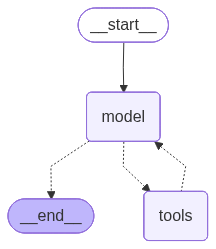

In [7]:
from langchain.agents import create_agent

agent = create_agent(
    model= 'gpt-5',
    tools =[get_weather],
    system_prompt=("What's the weather like in Boston?")
)
agent

### Tool Execution Loop

In [8]:
# Step 1: Model generates tool calls
messages = [{"role": "user", "content": "What's the weather in Boston?"}]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

# Step 2: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
    # Execute the tool with the generated arguments
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

# Step 3: Pass results back to model for final response
final_response = model_with_tools.invoke(messages)
print(final_response.text)
# "The current weather in Boston is 72°F and sunny."

The weather in Boston is sunny.


In [9]:
messages

[{'role': 'user', 'content': "What's the weather in Boston?"},
 AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city": "Boston"}'}, '__gemini_function_call_thought_signatures__': {'4074d788-14c5-4eea-9c05-934b8b36803a': 'Cv4BAXLI2nz7yDth/9dEghH8dH3lJAY64rTNGbaSnXTmbTTKZd4ci7XXlIjzzB3iREsAnzQxSqLzg4jIc45gjBsXFiF/7UxUv+pGuCdgr0WD3ALWRJYJX9JpWul9vS0hYF/A71bKprtgUTYSKe1oyrake++UZYIWlOdaecWap2i3TEH0SZ+RtICwbmGzCgV7prwJ2gTmD1wiOs7Dc584/o7Mx2JPUnffLx5zYQpVvprkYGooDOqrSroCgDdIO1rrVn3b2jPvapRJbUeIoX0hqFyEWidGnPE/C2PEiCM9WNYRo2cANnYnBEZCh06KhCu/++CEDITVPy22ODB/pSA7Xzg='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019be5e5-aa34-7903-9943-90ddc95164fd-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Boston'}, 'id': '4074d788-14c5-4eea-9c05-934b8b36803a', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 

In [27]:
import re
from langchain_openai import ChatOpenAI
from langchain_classic.agents import create_react_agent, AgentExecutor
from langchain_classic import hub
from langchain_classic.tools import tool

@tool
def search_web(query: str) -> str:
    """Useful for answering questions (demo tool)."""
    return "The CEO of LangChain is Harrison Chase."

@tool
def multiply(text: str) -> int:
    """Multiply two integers found in text like '5 and 5' or '(5, 5)'."""
    nums = list(map(int, re.findall(r"-?\d+", text)))
    if len(nums) < 2:
        raise ValueError("Need two integers.")
    return nums[0] * nums[1]

tools = [search_web, multiply]

llm = ChatOpenAI(model="gpt-4o", temperature=0)

prompt = hub.pull("hwchase17/react")  # classic ReAct prompt

agent = create_react_agent(llm, tools, prompt)

agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True,
    handle_parsing_errors=True,
)

response = agent_executor.invoke({"input": "Who is the CEO of LangChain and what is 5 times 5?"})
print(response["output"])




> Entering new AgentExecutor chain...
To answer the question, I need to find out who the CEO of LangChain is and then calculate 5 times 5.

Action: search_web
Action Input: "CEO of LangChain"The CEO of LangChain is Harrison Chase.I have found the CEO of LangChain. Now, I need to calculate 5 times 5.

Action: multiply
Action Input: "5 and 5"25I now know the final answer.

Final Answer: The CEO of LangChain is Harrison Chase, and 5 times 5 is 25.

> Finished chain.
The CEO of LangChain is Harrison Chase, and 5 times 5 is 25.
